# Intro

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa


EXPERIMENT_RANDOM_STATE = 42
random.seed(EXPERIMENT_RANDOM_STATE)
np.random.seed(EXPERIMENT_RANDOM_STATE)

root_dir = '../'
dataset_dir = os.path.join(root_dir, 'datasets')
dataset_dir_training = os.path.join(dataset_dir, 'opus/training')
dataset_dir_evaluation = os.path.join(dataset_dir, 'normal/evaluation')


features_dir = os.path.join(root_dir, 'features')
features_path_training = os.path.join(features_dir, 'opus-training.npz')
features_path_evaluation = os.path.join(features_dir, 'opus-evaluation.npz')

# model_dir = os.path.join(root_dir, 'models')
# cnn_model_path_training = os.path.join(model_dir, 'cnn_model-training.h5')
# svm_model_dir = os.path.join(model_dir, 'svm_model')
# svm_model_path = os.path.join(svm_model_dir, 'model.pkl')
# svm_scaler_path = os.path.join(svm_model_dir, 'scaler.pkl')
# svm_encoder_path = os.path.join(svm_model_dir, 'label_encoder.pkl')

fmin = librosa.note_to_hz('C1')
hop_length = 512
bins_per_octave = 36
sr_default = 48_000

# Read Features

In [2]:
if os.path.exists(features_path_training):
    training_data = np.load(features_path_training)
    exp_features = training_data['features']
    exp_labels = training_data['labels']
else:
    raise FileNotFoundError(f'Expected features file was not found: {features_path_training}')

if os.path.exists(features_path_evaluation):
  evaluation_data = np.load(features_path_evaluation)
  X_evaluation_cmp = np.asarray(evaluation_data["features"])
  y_evaluation_cmp = np.asarray(evaluation_data["labels"])
else:
  raise FileNotFoundError(f"No evaluation source found: {dataset_dir_evaluation}")

exp_features = np.asarray(exp_features)
exp_labels = np.asarray(exp_labels)
max_cqt_pad_len = exp_features.shape[2] if exp_features.ndim == 3 else 200

print(f'Loaded features: {exp_features.shape}')
print(f'Loaded labels:   {exp_labels.shape}')
print(f'Unique classes:  {len(np.unique(exp_labels))}')

Loaded features: (7200, 216, 188)
Loaded labels:   (7200,)
Unique classes:  36


# 1. Visualize What Is Inside A CQT Frame

Sample index: 642
Label: A_diminished_4
CQT shape (bins x frames): (216, 188)


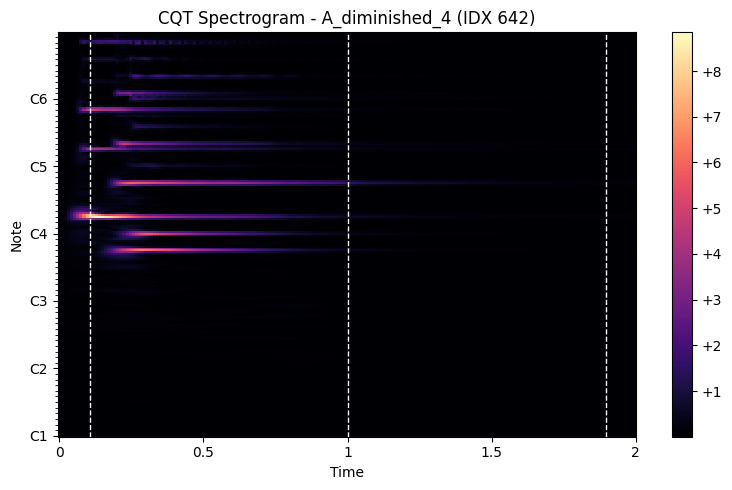

In [3]:
rng = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
import librosa.display

sample_idx = int(rng.integers(0, len(exp_features)))
sample_cqt = exp_features[sample_idx]
sample_label = exp_labels[sample_idx]

bins_per_note = bins_per_octave // 12
n_notes = int(np.ceil(sample_cqt.shape[0] / bins_per_note))

start_midi = librosa.note_to_midi("C1")
note_names = np.repeat(
    [librosa.midi_to_note(m, octave=True) for m in range(start_midi, start_midi + n_notes)],
    bins_per_note
)[:sample_cqt.shape[0]]

n_frames = sample_cqt.shape[1]
time_axis = np.arange(n_frames) * hop_length / sr_default

frame_a = min(10, n_frames - 1)
frame_b = n_frames // 2
frame_c = max(n_frames - 10, 0)
frame_points = [frame_a, frame_b, frame_c]

print(f'Sample index: {sample_idx}')
print(f'Label: {sample_label}')
print(f'CQT shape (bins x frames): {sample_cqt.shape}')

plt.figure(figsize=(8, 5))
librosa.display.specshow(
    sample_cqt,
    x_axis='time',
    y_axis='cqt_note',
    sr=sr_default,
    fmin=fmin,
    bins_per_octave=bins_per_octave,
    hop_length=hop_length,
)
for fp in frame_points:
    plt.axvline(fp * hop_length / sr_default, color='white', linestyle='--', linewidth=1)
plt.title(f'CQT Spectrogram - {sample_label} (IDX {sample_idx})')
plt.colorbar(format='%+2.0f')
plt.tight_layout()
plt.show()

### 1.1 Frame-Level Note Energy At Selected Time Steps

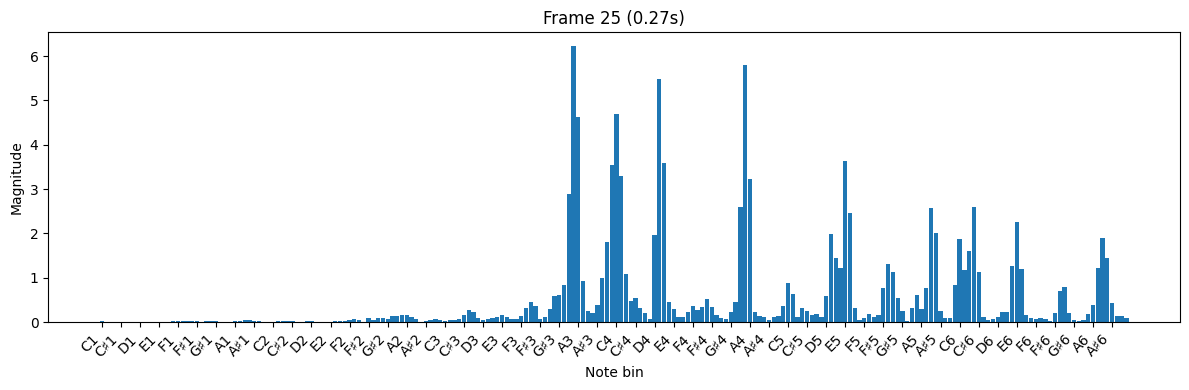

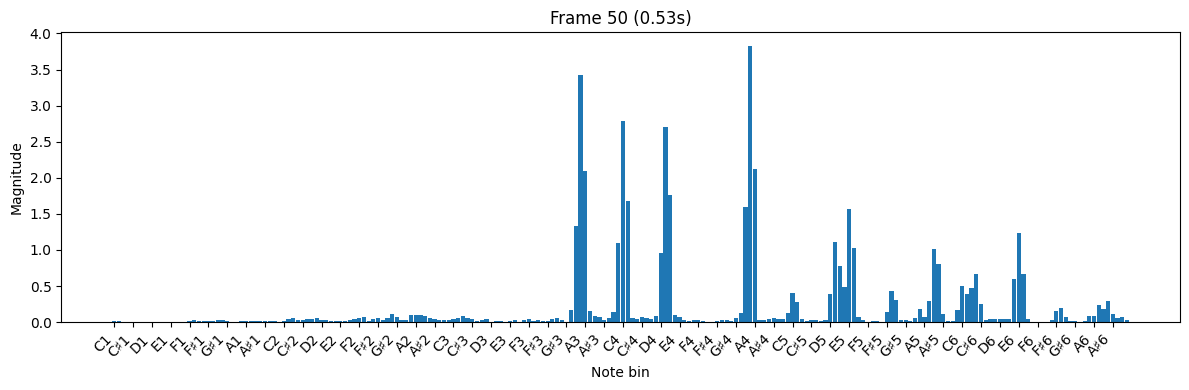

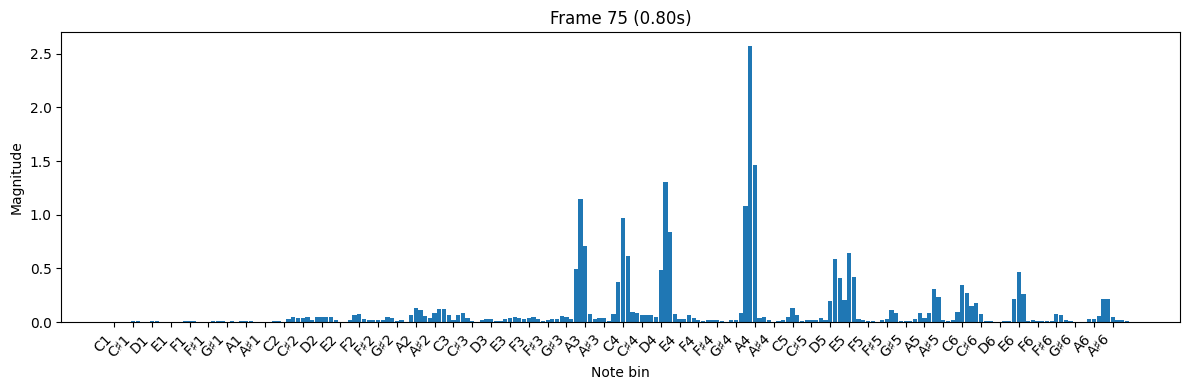

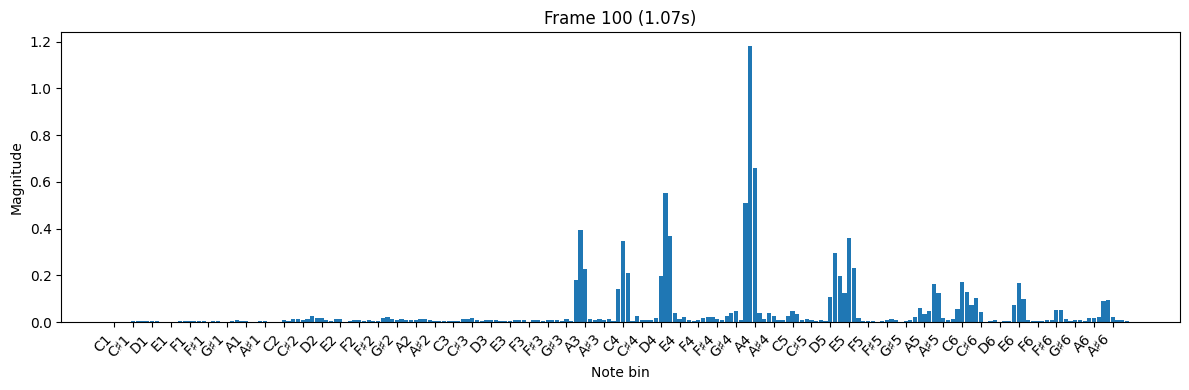

In [4]:
frame_points = [25, 50, 75, 100]
if sample_cqt.shape[1] <= max(frame_points):
    raise ValueError(f'Need at least {max(frame_points) + 1} frames, got {sample_cqt.shape[1]}')

for fp in frame_points:
    plt.figure(figsize=(12, 4))
    plt.bar(np.arange(len(note_names)), sample_cqt[:, fp], width=0.9)
    plt.title(f'Frame {fp} ({fp * hop_length / sr_default:.2f}s)')
    plt.xlabel('Note bin')
    plt.ylabel('Magnitude')
    plt.xticks(np.arange(len(note_names))[::4], note_names[::4], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 1.2 3D CQT Surface View

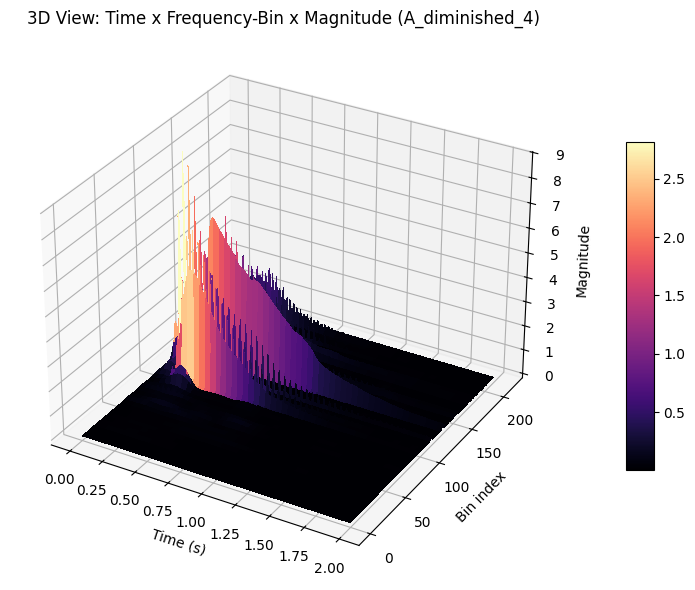

In [5]:
X, Y = np.meshgrid(time_axis, np.arange(sample_cqt.shape[0]))
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, sample_cqt, cmap='magma', linewidth=0, antialiased=False)
ax.set_title(f'3D View: Time x Frequency-Bin x Magnitude ({sample_label})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Bin index')
ax.set_zlabel('Magnitude')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

### 1.3 Data Frame Table

In [6]:
sample_df = pd.DataFrame(
    sample_cqt,
    index=note_names,
    columns=[f'frame_{i}' for i in range(sample_cqt.shape[1])],
    dtype=float,
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
  display(sample_df)

,frame_0,frame_1,frame_2,frame_3,frame_4,frame_5,frame_6,frame_7,frame_8,frame_9,frame_10,frame_11,frame_12,frame_13,frame_14,frame_15,frame_16,frame_17,frame_18,frame_19,frame_20,frame_21,frame_22,frame_23,frame_24,frame_25,frame_26,frame_27,frame_28,frame_29,frame_30,frame_31,frame_32,frame_33,frame_34,frame_35,frame_36,frame_37,frame_38,frame_39,frame_40,frame_41,frame_42,frame_43,frame_44,frame_45,frame_46,frame_47,frame_48,frame_49,frame_50,frame_51,frame_52,frame_53,frame_54,frame_55,frame_56,frame_57,frame_58,frame_59,frame_60,frame_61,frame_62,frame_63,frame_64,frame_65,frame_66,frame_67,frame_68,frame_69,frame_70,frame_71,frame_72,frame_73,frame_74,frame_75,frame_76,frame_77,frame_78,frame_79,frame_80,frame_81,frame_82,frame_83,frame_84,frame_85,frame_86,frame_87,frame_88,frame_89,frame_90,frame_91,frame_92,frame_93,frame_94,frame_95,frame_96,frame_97,frame_98,frame_99,frame_100,frame_101,frame_102,frame_103,frame_104,frame_105,frame_106,frame_107,frame_108,frame_109,frame_110,frame_111,frame_112,frame_113,frame_114,frame_115,frame_116,frame_117,frame_118,frame_119,frame_120,frame_121,frame_122,frame_123,frame_124,frame_125,frame_126,frame_127,frame_128,frame_129,frame_130,frame_131,frame_132,frame_133,frame_134,frame_135,frame_136,frame_137,frame_138,frame_139,frame_140,frame_141,frame_142,frame_143,frame_144,frame_145,frame_146,frame_147,frame_148,frame_149,frame_150,frame_151,frame_152,frame_153,frame_154,frame_155,frame_156,frame_157,frame_158,frame_159,frame_160,frame_161,frame_162,frame_163,frame_164,frame_165,frame_166,frame_167,frame_168,frame_169,frame_170,frame_171,frame_172,frame_173,frame_174,frame_175,frame_176,frame_177,frame_178,frame_179,frame_180,frame_181,frame_182,frame_183,frame_184,frame_185,frame_186,frame_187
C1,0.012850,0.013205,0.013553,0.013893,0.014223,0.014545,0.014856,0.015157,0.015446,0.015723,0.015988,0.016240,0.016479,0.016704,0.016915,0.017111,0.017292,0.017458,0.017608,0.017743,0.017862,0.017964,0.018051,0.018121,0.018174,0.018211,0.018232,0.018236,0.018223,0.018194,0.018148,0.018085,0.018006,0.017910,0.017799,0.017671,0.017528,0.017368,0.017193,0.017003,0.016798,0.016578,0.016344,0.016095,0.015833,0.015558,0.015269,0.014968,0.014655,0.014331,0.013995,0.013649,0.013293,0.012928,0.012555,0.012173,0.011785,0.011390,0.010990,0.010585,0.010176,0.009763,0.009349,0.008934,0.008518,0.008102,0.007689,0.007278,0.006871,0.006469,0.006073,0.005685,0.005305,0.004936,0.004578,0.004233,0.003904,0.003592,0.003300,0.003030,0.002785,0.002568,0.002384,0.002234,0.002121,0.002046,0.002007,0.002001,0.002024,0.002070,0.002132,0.002205,0.002285,0.002367,0.002449,0.002529,0.002603,0.002672,0.002734,0.002789,0.002835,0.002873,0.002904,0.002926,0.002940,0.002946,0.002945,0.002937,0.002922,0.002900,0.002873,0.002841,0.002804,0.002763,0.002718,0.002669,0.002618,0.002565,0.002510,0.002454,0.002396,0.002338,0.002280,0.002223,0.002166,0.002109,0.002054,0.002001,0.001949,0.001898,0.001850,0.001804,0.001760,0.001718,0.001678,0.001640,0.001605,0.001572,0.001541,0.001513,0.001486,0.001459,0.001435,0.001413,0.001393,0.001372,0.001351,0.001333,0.001316,0.001301,0.001285,0.001270,0.001254,0.001241,0.001226,0.001214,0.001203,0.001194,0.001184,0.001176,0.001168,0.001161,0.001154,0.001151,0.001148,0.001147,0.001146,0.001143,0.001144,0.001146,0.001147,0.001150,0.001152,0.001155,0.001157,0.001160,0.001162,0.001167,0.001169,0.001173,0.001178,0.001181,0.001185,0.001185,0.001189,0.001191,0.001194,0.001196
C1,0.010982,0.011252,0.011516,0.011775,0.012027,0.012269,0.012506,0.012735,0.012954,0.013167,0.013368,0.013561,0.013744,0.013915,0.014076,0.014229,0.014371,0.014499,0.014617,0.014724,0.014817,0.014902,0.014971,0.015030,0.015074,0.015109,0.015129,0.015137,0.015133,0.015115,0.015086,0.015043,0.014991,0.014925,0.014847,0.014756,0.014653,0.014539,0.014414,0.014280,0.014134,0.013978,0.013810,0.013634,0.013450,0.013255,0.013052,0.012842,0.012623,0.012399,0.012167,0.011931,0.011686,0.011439,0.011186,0.010930,0.010671,0.010408,0.010142,

# 2. Group Visualization

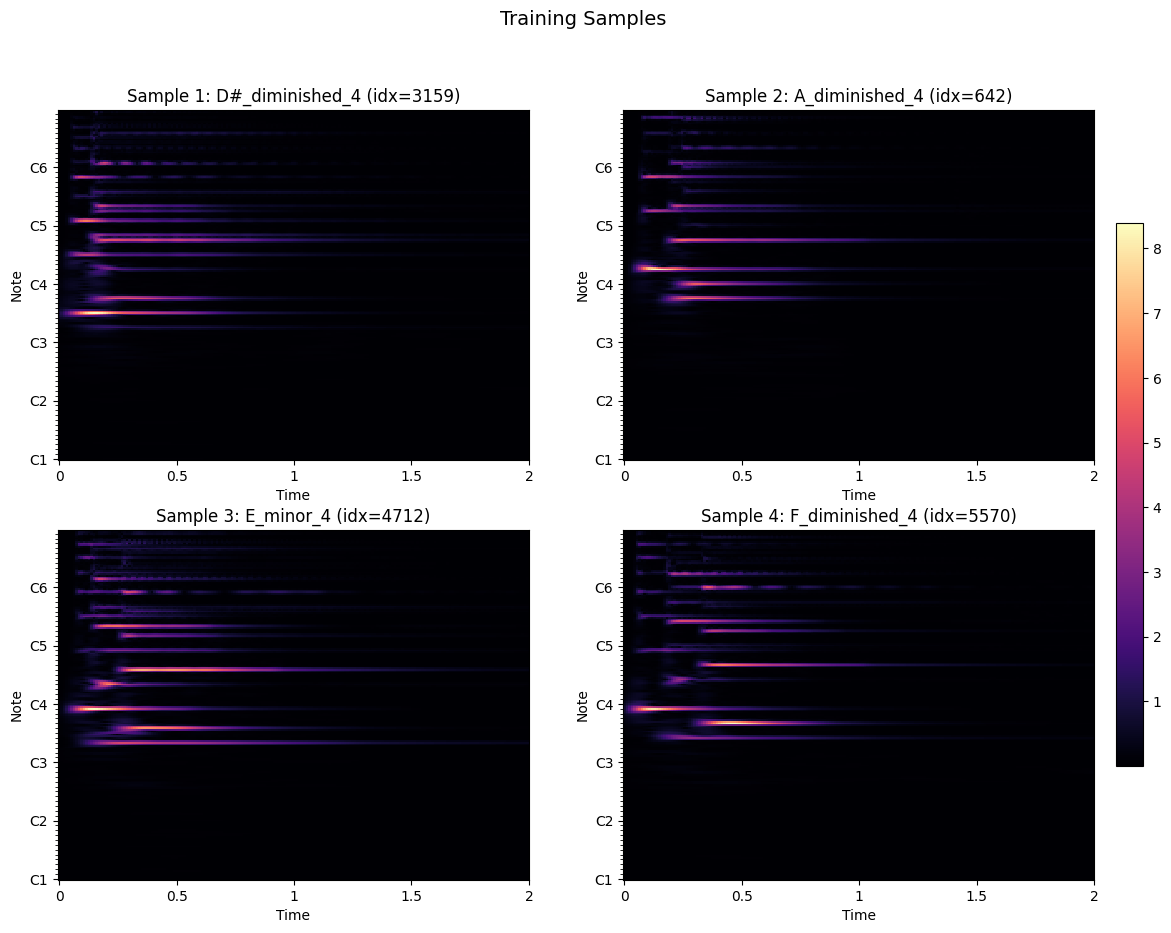

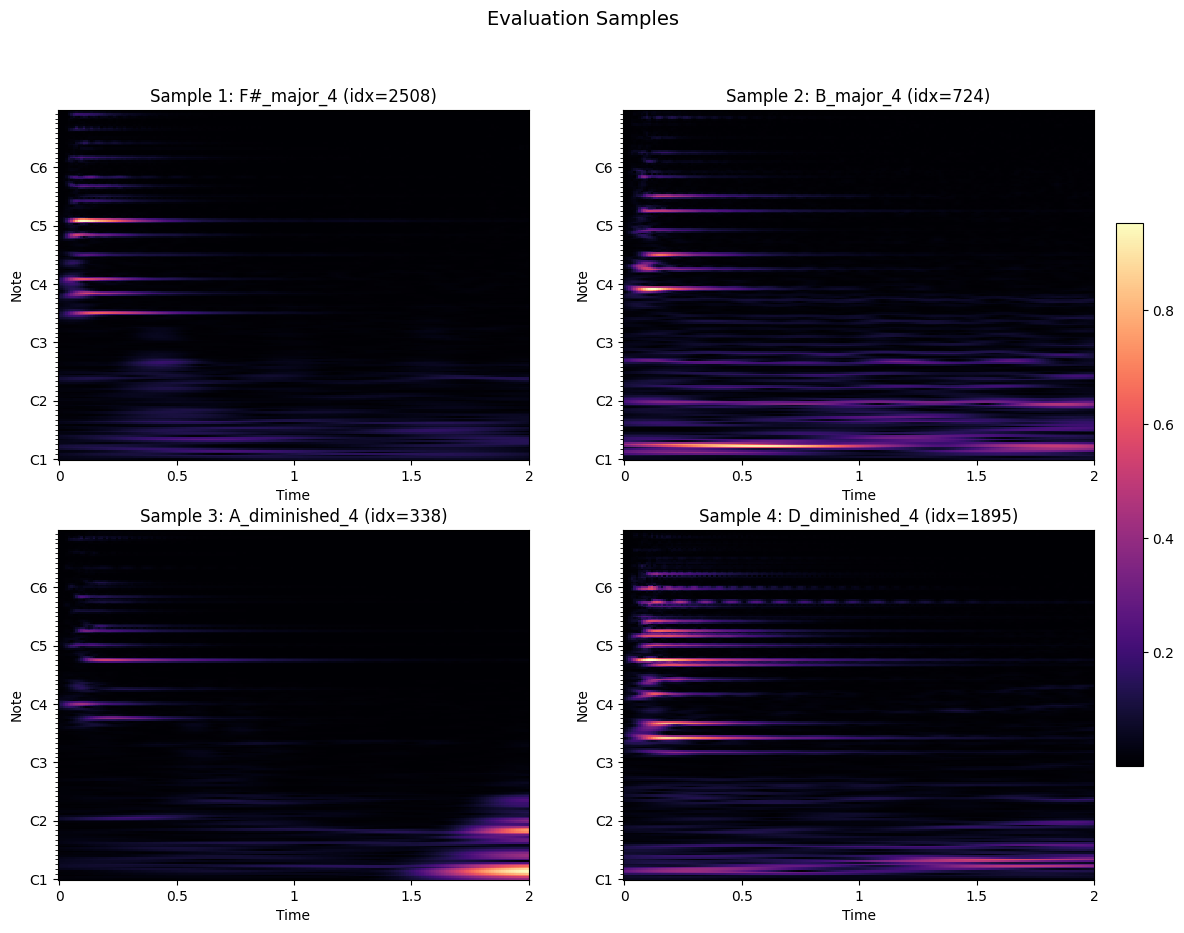

In [7]:
rng_group = np.random.default_rng(EXPERIMENT_RANDOM_STATE)

def plot_random_cqt_grid(features, labels, title, n_samples=4):
    if features.ndim != 3:
        raise RuntimeError(f'Expected features with shape (N, bins, frames), got {features.shape}')

    n_show = min(n_samples, len(features))
    if n_show == 0:
        raise RuntimeError(f'No samples available for {title.lower()}')

    sample_indices = rng_group.choice(len(features), size=n_show, replace=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)
    axes_flat = axes.flatten()

    # vmin = float(np.percentile(features[sample_indices], 2))
    # vmax = float(np.percentile(features[sample_indices], 98))
    last_im = None

    for sample_number, (ax, sample_idx) in enumerate(zip(axes_flat, sample_indices), start=1):
        sample_cqt = features[sample_idx]
        sample_label = labels[sample_idx]
        last_im = librosa.display.specshow(
            sample_cqt,
            ax=ax,
            x_axis='time',
            y_axis='cqt_note',
            sr=sr_default,
            fmin=fmin,
            bins_per_octave=bins_per_octave,
            hop_length=hop_length,
            cmap='magma',
            # vmin=vmin,
            # vmax=vmax,
        )
        ax.set_title(f'Sample {sample_number}: {sample_label} (idx={int(sample_idx)})')
        ax.set_xlabel('Time')
        ax.set_ylabel('Note')

    for ax in axes_flat[n_show:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    plt.show()

plot_random_cqt_grid(
    np.asarray(training_data['features']),
    np.asarray(training_data['labels']),
    'Training Samples',
)

plot_random_cqt_grid(
    np.asarray(evaluation_data['features']),
    np.asarray(evaluation_data['labels']),
    'Evaluation Samples',
)

# 3. Training vs evaluation dataset

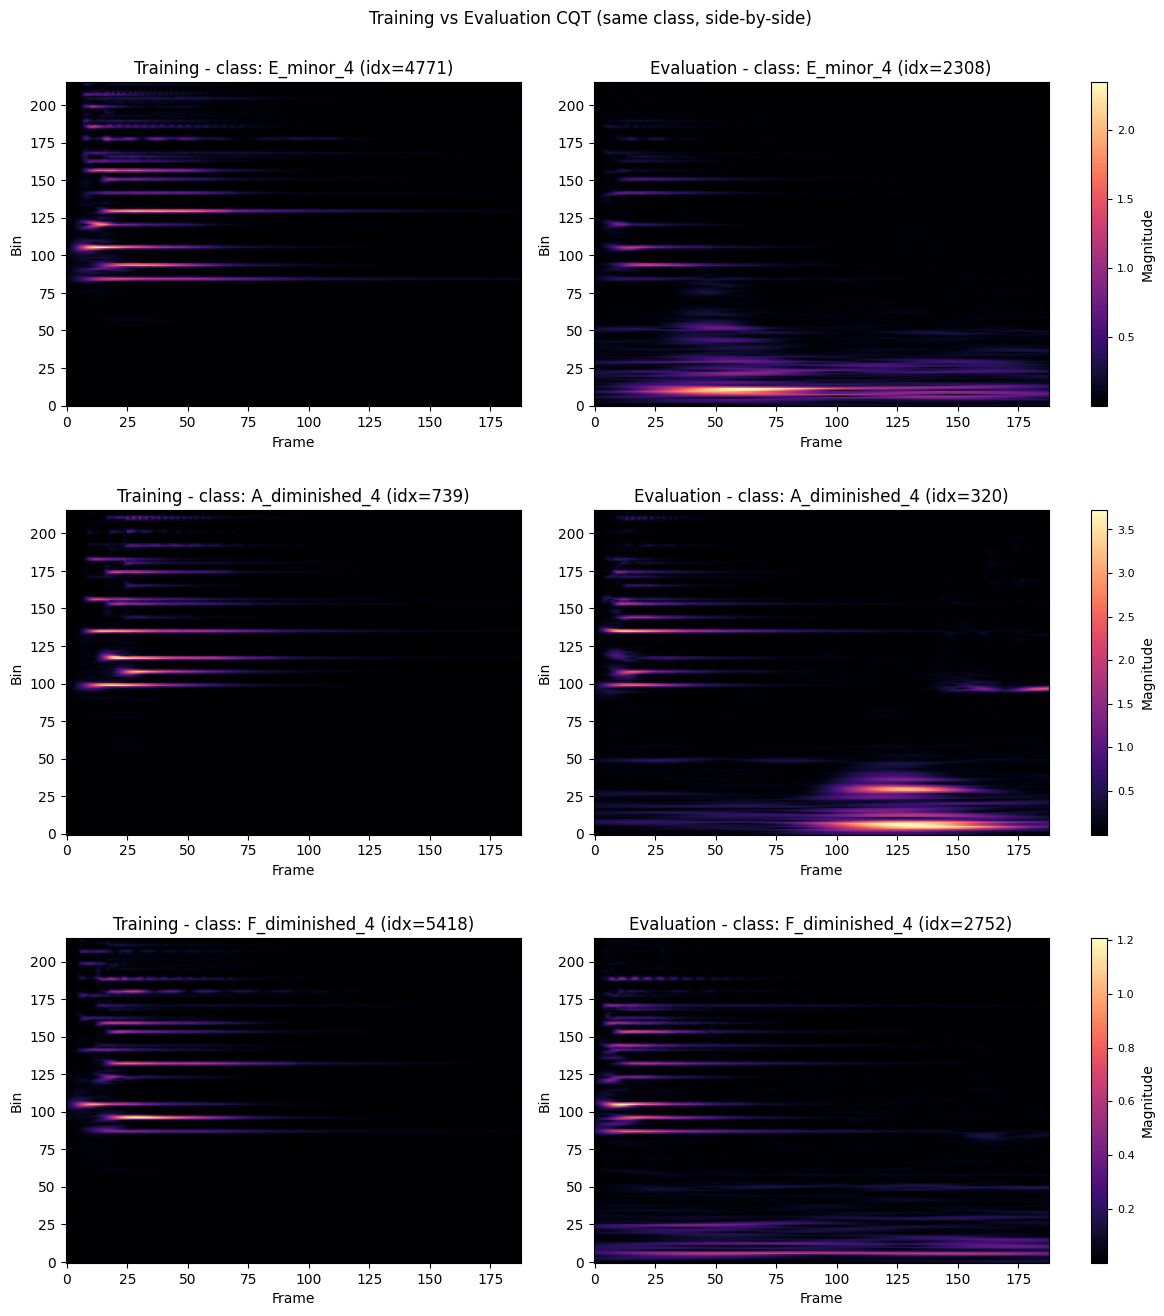

In [8]:
target_bins = exp_features.shape[1]
target_frames = exp_features.shape[2]

# Align evaluation shape to training feature basis
if X_evaluation_cmp.ndim != 3:
  raise RuntimeError(f"Expected evaluation features shape (N,bins,frames), got: {X_evaluation_cmp.shape}")

# Pick 3 classes existing in both training and evaluation sets
common_classes = np.intersect1d(np.unique(exp_labels), np.unique(y_evaluation_cmp))
if len(common_classes) == 0:
  raise RuntimeError("No overlapping classes between training and evaluation labels.")

n_classes_show = min(3, len(common_classes))
rng_cmp = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
classes_show = rng_cmp.choice(common_classes, size=n_classes_show, replace=False)

fig, axes = plt.subplots(
  n_classes_show,
  2,
  figsize=(14, 4.8 * n_classes_show),
  # squeeze=False,
)
fig.subplots_adjust(hspace=0.32, wspace=0.16, top=0.93, right=0.88)

for r, cls in enumerate(classes_show):
  training_idx_all = np.where(exp_labels == cls)[0]
  evaluation_idx_all = np.where(y_evaluation_cmp == cls)[0]

  training_idx = int(rng_cmp.choice(training_idx_all))
  evaluation_idx = int(rng_cmp.choice(evaluation_idx_all))

  training_cqt = exp_features[training_idx]
  evaluation_cqt = X_evaluation_cmp[evaluation_idx]

  # Shared color range per class pair
  # pair_stack = np.stack([training_cqt, evaluation_cqt], axis=0)
  # vmin = float(np.percentile(pair_stack, 2))
  # vmax = float(np.percentile(pair_stack, 98))

  im0 = axes[r, 0].imshow(
    training_cqt,
    aspect="auto",
    origin="lower",
    cmap="magma",
    # vmin=vmin,
    # vmax=vmax,
)
  axes[r, 0].set_title(f"Training - class: {cls} (idx={training_idx})")
  axes[r, 0].set_xlabel("Frame")
  axes[r, 0].set_ylabel("Bin")

  im1 = axes[r, 1].imshow(
    evaluation_cqt,
    aspect="auto",
    origin="lower",
    cmap="magma",
    # vmin=vmin,
    # vmax=vmax,
)
  axes[r, 1].set_title(f"Evaluation - class: {cls} (idx={evaluation_idx})")
  axes[r, 1].set_xlabel("Frame")
  axes[r, 1].set_ylabel("Bin")

  cbar = fig.colorbar(im1, ax=axes[r, :], fraction=0.03, pad=0.04)
  cbar.ax.tick_params(labelsize=8)
  cbar.set_label('Magnitude')

fig.suptitle("Training vs Evaluation CQT (same class, side-by-side)")
plt.show()

# 4. Plot Evaluation CQT Feature Samples

In [9]:
import librosa.display

n_show = min(6, len(X_evaluation))
rng_evaluation_plot = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
show_idx = rng_evaluation_plot.choice(len(X_evaluation), size=n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), squeeze=False)

for ax, idx in zip(axes.flatten(), show_idx):
    librosa.display.specshow(
        X_evaluation[idx],
        x_axis='time',
        y_axis='cqt_note',
        sr=sr_default,
        fmin=fmin,
        bins_per_octave=bins_per_octave,
        hop_length=hop_length,
        ax=ax,
    )
    ax.set_title(f'Evaluation sample: {y_evaluation_labels[idx]} (idx={int(idx)})')
    ax.set_xlabel('Time')
    ax.set_ylabel('Note')

for ax in axes.flatten()[n_show:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'X_evaluation' is not defined